In [1]:
import os
import glob
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# 1. Define target horizons and model mappings
target_horizons = [7, 14, 30]

# Mapping prefix in filename to display name
model_map = {
    "gbr_random": "Gradient Boosting (Random)",
    "lr_random": "Linear Regression (Random)",
    "m5p_random": "M5P (Random)",
    "rf_random": "Random Forest (Random)",
    "xgbr_random": "XGBoost (Random)"
}

# 2. Metric calculation function
def compute_metrics(group):
    actual = group['actual']
    predicted = group['predicted']
    
    # Mean Squared Error (MSE)
    mse = np.mean((actual - predicted) ** 2)
    
    # Root Mean Squared Error (RMSE)
    rmse = np.sqrt(mse)
    
    # Pearson Correlation (R)
    if len(actual) > 1 and np.std(actual) > 0 and np.std(predicted) > 0:
        r, _ = pearsonr(actual, predicted)
    else:
        r = np.nan
        
    # Relative Absolute Error (RAE %)
    mean_actual = np.mean(actual)
    mae_model = np.sum(np.abs(actual - predicted))
    mae_naive = np.sum(np.abs(actual - mean_actual))
    rae = (mae_model / mae_naive) * 100 if mae_naive != 0 else np.nan
    
    # Mean Absolute Percentage Error (MAPE %)
    valid_mask = actual != 0
    if np.any(valid_mask):
        mape = np.mean(np.abs((actual[valid_mask] - predicted[valid_mask]) / actual[valid_mask])) * 100
    else:
        mape = np.nan
    
    return pd.Series({
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'R': round(r, 4),
        'RAE (%)': round(rae, 2),
        'MAPE (%)': round(mape, 2)
    })

# 3. Outer loop over target folders, inner loop over model CSVs
all_results = []

for h in target_horizons:
    folder_name = f"target_{h}"
    print(f"\n--- Processing Directory: ./{folder_name}/ ---")
    
    for prefix, model_name in model_map.items():
        file_name = f"{prefix}_buffer_{h}.csv"
        file_path = os.path.join(folder_name, file_name)
        
        if os.path.exists(file_path):
            print(f"Processing: {model_name} -> {file_path}")
            df = pd.read_csv(file_path)
            df.columns = df.columns.str.strip()
            
            # Calculate per-commodity metrics for this model
            metrics_df = df.groupby('commodity_name', group_keys=False).apply(compute_metrics).reset_index()
            
            # Insert Target_Horizon and Model columns
            metrics_df.insert(0, 'Target_Horizon', f"target_{h}")
            metrics_df.insert(1, 'Model', model_name)
            
            all_results.append(metrics_df)
        else:
            print(f"Warning: File not found -> {file_path}")

# 4. Combine all results into a single DataFrame
if all_results:
    combined_df = pd.concat(all_results, ignore_index=True)

    # Sort by Target_Horizon, commodity_name, and Model
    combined_df = combined_df.sort_values(by=['Target_Horizon', 'commodity_name', 'Model']).reset_index(drop=True)

    # 5. Save master CSV
    output_csv = "all_models_per_product_evaluation_metrics_random.csv"
    combined_df.to_csv(output_csv, index=False)

    print(f"\nCompleted! Consolidated metrics saved to: {output_csv}")
    print("\nPreview of combined dataset:")
    display(combined_df.head(10))
else:
    print("\nNo matching files found. Check your relative paths.")


--- Processing Directory: ./target_7/ ---
Processing: Gradient Boosting (Random) -> target_7\gbr_random_buffer_7.csv
Processing: Linear Regression (Random) -> target_7\lr_random_buffer_7.csv
Processing: M5P (Random) -> target_7\m5p_random_buffer_7.csv
Processing: Random Forest (Random) -> target_7\rf_random_buffer_7.csv
Processing: XGBoost (Random) -> target_7\xgbr_random_buffer_7.csv

--- Processing Directory: ./target_14/ ---
Processing: Gradient Boosting (Random) -> target_14\gbr_random_buffer_14.csv
Processing: Linear Regression (Random) -> target_14\lr_random_buffer_14.csv
Processing: M5P (Random) -> target_14\m5p_random_buffer_14.csv
Processing: Random Forest (Random) -> target_14\rf_random_buffer_14.csv
Processing: XGBoost (Random) -> target_14\xgbr_random_buffer_14.csv

--- Processing Directory: ./target_30/ ---
Processing: Gradient Boosting (Random) -> target_30\gbr_random_buffer_30.csv
Processing: Linear Regression (Random) -> target_30\lr_random_buffer_30.csv
Processing: M5

,Target_Horizon,Model,commodity_name,MSE,RMSE,R,RAE (%),MAPE (%)
0,target_14,Gradient Boosting (Random),'Ata (Packet)',3.4450,1.8561,0.7404,68.82,2.53
1,target_14,Linear Regression (Random),'Ata (Packet)',2.8604,1.6913,0.7367,66.76,2.45
2,target_14,M5P (Random),'Ata (Packet)',6.8423,2.6158,0.7713,104.06,3.77
3,target_14,Random Forest (Random),'Ata (Packet)',4.5839,2.1410,0.8159,88.32,3.25
4,target_14,XGBoost (Random),'Ata (Packet)',1.6972,1.3028,0.8567,48.12,1.78
5,target_14,Gradient Boosting (Random),'Ata (loose) - White',6.2084,2.4917,0.6377,65.73,3.82
6,target_14,Linear Regression (Random),'Ata (loose) - White',7.6453,2.7650,0.5360,82.85,4.88
7,target_14,M5P (Random),'Ata (loose) - White',6.5266,2.5547,0.6381,55.36,3.25
8,target_14,Random Forest (Random),'Ata (loose) - White',9.1512,3.0251,0.6792,93.84,5.55
9,target_14,XGBoost (Random),'Ata (loose) - White',4.3280,2.0804,0.7618,52.92,3.08


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('all_models_per_product_evaluation_metrics_random.csv')

# Set style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Calculate average metrics grouped by Model and Target_Horizon
avg_df = df.groupby(['Model', 'Target_Horizon']).agg({
    'R': 'mean',
    'RAE (%)': 'mean',
    'MAPE (%)': 'mean',
    'RMSE': 'mean'
}).reset_index()

# Set categorical order
model_order = ['XGBoost (Random)', 'M5P (Random)', 'Gradient Boosting (Random)', 'Random Forest (Random)', 'Linear Regression (Random)']
target_order = ['target_7', 'target_14', 'target_30']

avg_df['Model'] = pd.Categorical(avg_df['Model'], categories=model_order, ordered=True)
avg_df['Target_Horizon'] = pd.Categorical(avg_df['Target_Horizon'], categories=target_order, ordered=True)
avg_df = avg_df.sort_values(['Target_Horizon', 'Model'])

# Plot 1: Pearson R
sns.barplot(data=avg_df, x='Model', y='R', hue='Target_Horizon', ax=axes[0, 0], palette='Blues_d')
axes[0, 0].set_title('Average Pearson Correlation (R) ↑ Higher is Better', fontsize=12, fontweight='bold')
axes[0, 0].set_ylim(0.0, 1.0)

# Plot 2: RAE (%)
sns.barplot(data=avg_df, x='Model', y='RAE (%)', hue='Target_Horizon', ax=axes[0, 1], palette='Oranges_d')
axes[0, 1].set_title('Average Relative Absolute Error (RAE %) ↓ Lower is Better', fontsize=12, fontweight='bold')

# Plot 3: MAPE (%)
sns.barplot(data=avg_df, x='Model', y='MAPE (%)', hue='Target_Horizon', ax=axes[1, 0], palette='Greens_d')
axes[1, 0].set_title('Average MAPE (%) ↓ Lower is Better', fontsize=12, fontweight='bold')

# Plot 4: RMSE
sns.barplot(data=avg_df, x='Model', y='RMSE', hue='Target_Horizon', ax=axes[1, 1], palette='Purples_d')
axes[1, 1].set_title('Average RMSE ↓ Lower is Better', fontsize=12, fontweight='bold')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('model_comparison_metrics_horizons_random.png', dpi=300)
plt.close()
print("Chart generated successfully as 'model_comparison_metrics_horizons.png'!")

Chart generated successfully as 'model_comparison_metrics_horizons.png'!


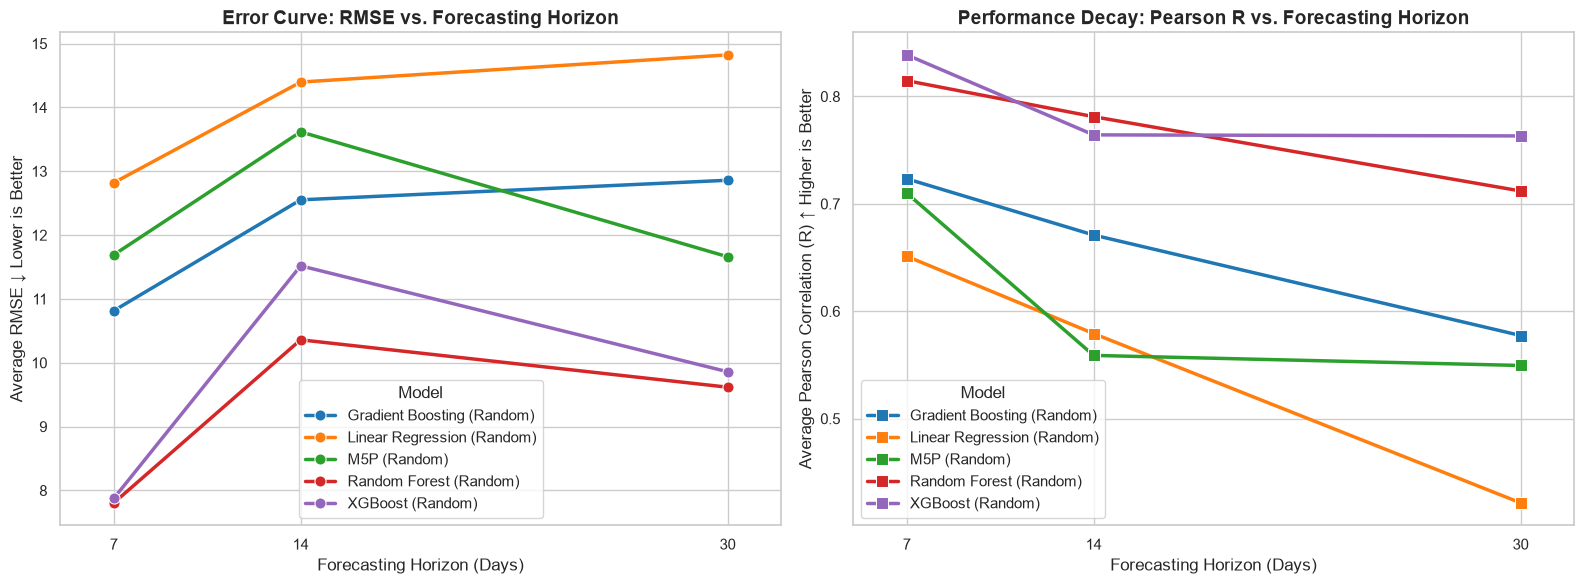

Learning curve generated and saved as 'temporal_learning_curve.png'!


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the consolidated metrics dataset
df = pd.read_csv('all_models_per_product_evaluation_metrics_random.csv')

# 2. Extract numeric horizon values (7, 14, 30) for a proper continuous X-axis
df['Horizon_Days'] = df['Target_Horizon'].str.extract(r'(\d+)').astype(int)

# 3. Calculate the average metrics for each Model at each Horizon
agg_df = df.groupby(['Model', 'Horizon_Days'])[['RMSE', 'R']].mean().reset_index()

# 4. Set up the visualization style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define a cohesive color palette for the models
palette = sns.color_palette("tab10", n_colors=df['Model'].nunique())

# Plot 1: Error Curve (RMSE vs. Horizon)
sns.lineplot(
    data=agg_df, 
    x='Horizon_Days', 
    y='RMSE', 
    hue='Model', 
    marker='o', 
    markersize=8, 
    linewidth=2.5, 
    palette=palette, 
    ax=axes[0]
)
axes[0].set_title('Error Curve: RMSE vs. Forecasting Horizon', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Forecasting Horizon (Days)', fontsize=12)
axes[0].set_ylabel('Average RMSE ↓ Lower is Better', fontsize=12)
axes[0].set_xticks([7, 14, 30])
axes[0].set_xlim(5, 32)

# Plot 2: Performance Decay Curve (Pearson R vs. Horizon)
sns.lineplot(
    data=agg_df, 
    x='Horizon_Days', 
    y='R', 
    hue='Model', 
    marker='s', 
    markersize=8, 
    linewidth=2.5, 
    palette=palette, 
    ax=axes[1]
)
axes[1].set_title('Performance Decay: Pearson R vs. Forecasting Horizon', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Forecasting Horizon (Days)', fontsize=12)
axes[1].set_ylabel('Average Pearson Correlation (R) ↑ Higher is Better', fontsize=12)
axes[1].set_xticks([7, 14, 30])
axes[1].set_xlim(5, 32)

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig('temporal_learning_curve_random.png', dpi=300)
plt.show()

print("Learning curve generated and saved as 'temporal_learning_curve.png'!")